<a href="https://colab.research.google.com/github/astridcvr/daily-ml-practice/blob/main/day_22_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading datasets from GitHub...

Shapes:
X_train_num: (2258, 8)  X_test_num: (565, 8)

Data standardized successfully.

Running PCA...


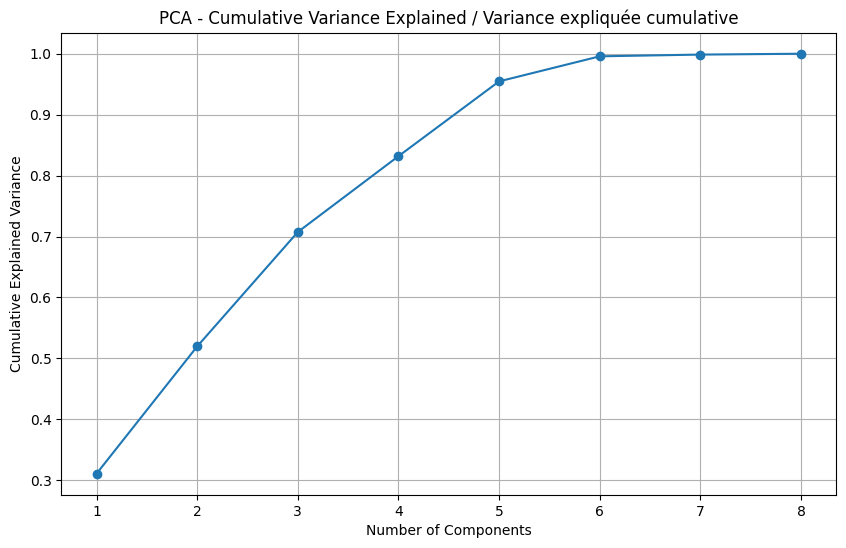


Optimal number of components to retain 95% variance: 5

Reduced dataset shape: (2258, 5)


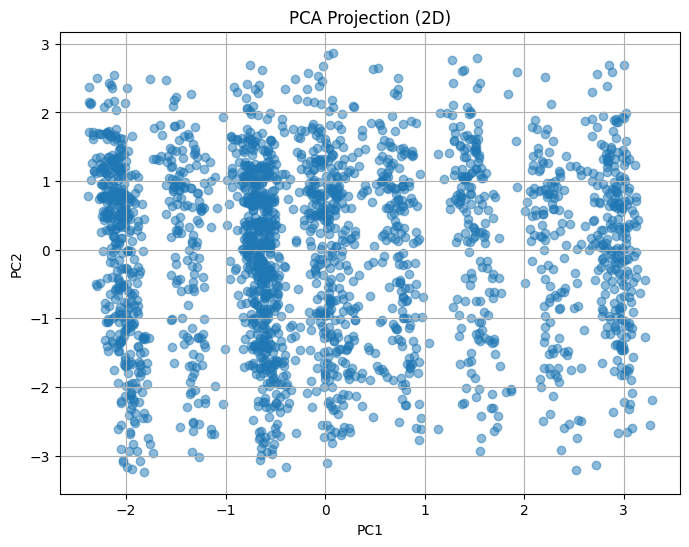


PCA variance explained saved locally: day_22_pca_components.csv
   Component  ExplainedVariance  CumulativeVariance
0          1           0.310730            0.310730
1          2           0.208860            0.519590
2          3           0.187789            0.707379
3          4           0.124467            0.831846
4          5           0.122777            0.954623
5          6           0.041108            0.995731
6          7           0.002847            0.998578
7          8           0.001422            1.000000


In [ ]:
# ============================================================
# Day 22 - PCA / ACP
# Dimensionality Reduction with Principal Component Analysis
#
# Author: Astrid Villalobos
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -------------------------------------------
# Load datasets
# -------------------------------------------
print("Loading datasets from GitHub...\n")

train_url = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/X_train.csv"
test_url = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/X_test.csv"

X_train = pd.read_csv(train_url)
X_test = pd.read_csv(test_url)

# Select numeric columns only
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

print("Shapes:")
print(f"X_train_num: {X_train_num.shape}  X_test_num: {X_test_num.shape}")

# -------------------------------------------
# Standardize data
# -------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_num)

print("\nData standardized successfully.")

# -------------------------------------------
# PCA - Fit model
# -------------------------------------------
print("\nRunning PCA...")

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cum_variance = explained_variance.cumsum()

# -------------------------------------------
# Plot explained variance
# -------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cum_variance, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Variance Explained / Variance expliquée cumulative")
plt.grid()
plt.show()

# Determine optimal number of components (retain 95% variance)
n_components_optimal = np.argmax(cum_variance >= 0.95) + 1
print(f"\nOptimal number of components to retain 95% variance: {n_components_optimal}")

# -------------------------------------------
# Reduce dimensionality
# -------------------------------------------
pca_final = PCA(n_components=n_components_optimal)
X_pca = pca_final.fit_transform(X_scaled)

print(f"\nReduced dataset shape: {X_pca.shape}")

# -------------------------------------------
# PCA 2D Projection for Visualization
# -------------------------------------------
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D)")
plt.grid()
plt.show()

# -------------------------------------------
# Save PCA results
# -------------------------------------------
save_path = "day_22_pca_components.csv"

df_pca = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "ExplainedVariance": explained_variance,
    "CumulativeVariance": cum_variance,
})

df_pca.to_csv(save_path, index=False)

print(f"\nPCA variance explained saved locally: {save_path}")
print(df_pca.head(10))
